# Práctica: Regresión no lineal con modelos polinomiales

## Objetivo de la práctica

En esta práctica estudiaremos cómo modelar una relación **no lineal** entre dos variables usando una idea sencilla: transformar la variable explicativa mediante potencias.

Trabajaremos con la base de datos `Auto`, en particular con la relación entre:

- `horsepower`: potencia del automóvil.
- `mpg`: millas por galón, es decir, rendimiento de combustible.

La pregunta central será:

> ¿Cómo cambia el rendimiento de combustible de un automóvil cuando aumenta su potencia?

Aunque usaremos herramientas de regresión lineal, el modelo puede representar curvas porque incluiremos términos como $x^2$, $x^3$, etc.


## 1. Importación de librerías

Primero cargamos las librerías necesarias. Estas librerías permiten:

- Leer y manipular datos.
- Graficar relaciones entre variables.
- Ajustar modelos de regresión.
- Evaluar la calidad del ajuste.

La práctica usa principalmente `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.


In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Procesado y modelado
from scipy.stats import pearsonr
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from scipy import stats

# Configuración de matplotlib
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carga de la base de datos

La base de datos se llama `Auto.csv`. Si trabajas en Google Colab, puedes subir el archivo directamente al entorno o montarlo desde Drive.



In [22]:

auto = pd.read_csv("/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 3/Auto.csv")
print(auto.shape)
auto.head()


(397, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 3. Exploración inicial de los datos

Antes de ajustar cualquier modelo, conviene revisar la estructura de la base de datos.

Algunas preguntas útiles son:

- ¿Cuántas observaciones tiene la base?
tiene 397 observaciones
- ¿Qué variables contiene?
tiene 9 variables: mpg, cylinders, displacement, horsepower, weight, acceleration, year, origin y name
- ¿Hay valores faltantes?
no la base no tiene valores faltantes
- ¿Qué tipo de variable es cada columna?
mpg, displacement y acceleration son numericas decimales , el cylinders, weight, year y origin son numericas enteras y horsepower y name son variables de texto
- ¿Qué valores mínimos, máximos y promedios aparecen?
son muy variados pero por ejemplo en mpg el valor minimo es 9, el maximo es 46.6 y el promedio es 23.5 esto muestra que hay autos con diferentes niveles de rendimiento de combustible

In [4]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [5]:
auto.describe()


,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


La descripción de las variables puede consultarse en la documentación de la base `Auto` del paquete ISLR.

En esta práctica nos concentraremos en dos variables:

- `mpg`: variable respuesta o variable objetivo.
- `horsepower`: variable explicativa o predictor.


## 4. Limpieza de datos

La columna `horsepower` contiene algunos registros con el símbolo `?`. Ese símbolo indica que el dato no está disponible.

Para poder ajustar modelos numéricos, necesitamos:

1. Reemplazar `?` por valores faltantes (`NaN`).
2. Eliminar las filas con valores faltantes.
3. Convertir `horsepower` a tipo numérico.
4. Ordenar los datos por `horsepower` para que las curvas se vean correctamente en las gráficas.


In [6]:
auto['horsepower'] = auto['horsepower'].replace('?', np.nan)
auto.isna().sum()

#isna


,0
mpg,0
cylinders,0
displacement,0
horsepower,5
weight,0
acceleration,0
year,0
origin,0
name,0


In [7]:
auto = auto.dropna()
auto['horsepower'] = auto['horsepower'].astype(int)
auto = auto.sort_values(by=['horsepower'], ascending=True)

auto.isna().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
year,0
origin,0
name,0


In [8]:
auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
19,26.0,4,97.0,46,1835,20.5,70,2,volkswagen 1131 deluxe sedan
102,26.0,4,97.0,46,1950,21.0,73,2,volkswagen super beetle
325,44.3,4,90.0,48,2085,21.7,80,2,vw rabbit c (diesel)
326,43.4,4,90.0,48,2335,23.7,80,2,vw dasher (diesel)
244,43.1,4,90.0,48,1985,21.5,78,2,volkswagen rabbit custom diesel


## 5. Análisis exploratorio

Ahora observamos gráficamente la relación entre las variables.

En particular, nos interesa revisar si la relación entre `horsepower` y `mpg` parece lineal o si tiene forma curva.


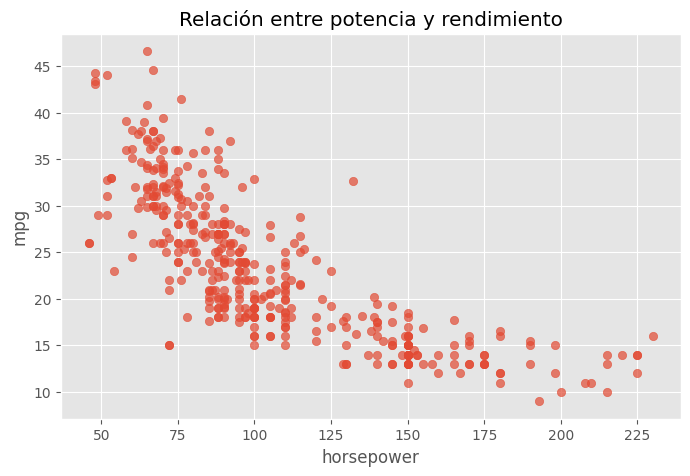

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(auto['horsepower'], auto['mpg'], alpha=0.7)
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Relación entre potencia y rendimiento')
plt.show()


### Interpretación inicial

En la gráfica se observa una relación negativa: cuando aumenta `horsepower`, tiende a disminuir `mpg`.

Sin embargo, la caída no parece perfectamente recta. Esto sugiere que un modelo lineal simple puede no capturar completamente la forma de la relación.

Por eso probaremos modelos polinomiales.


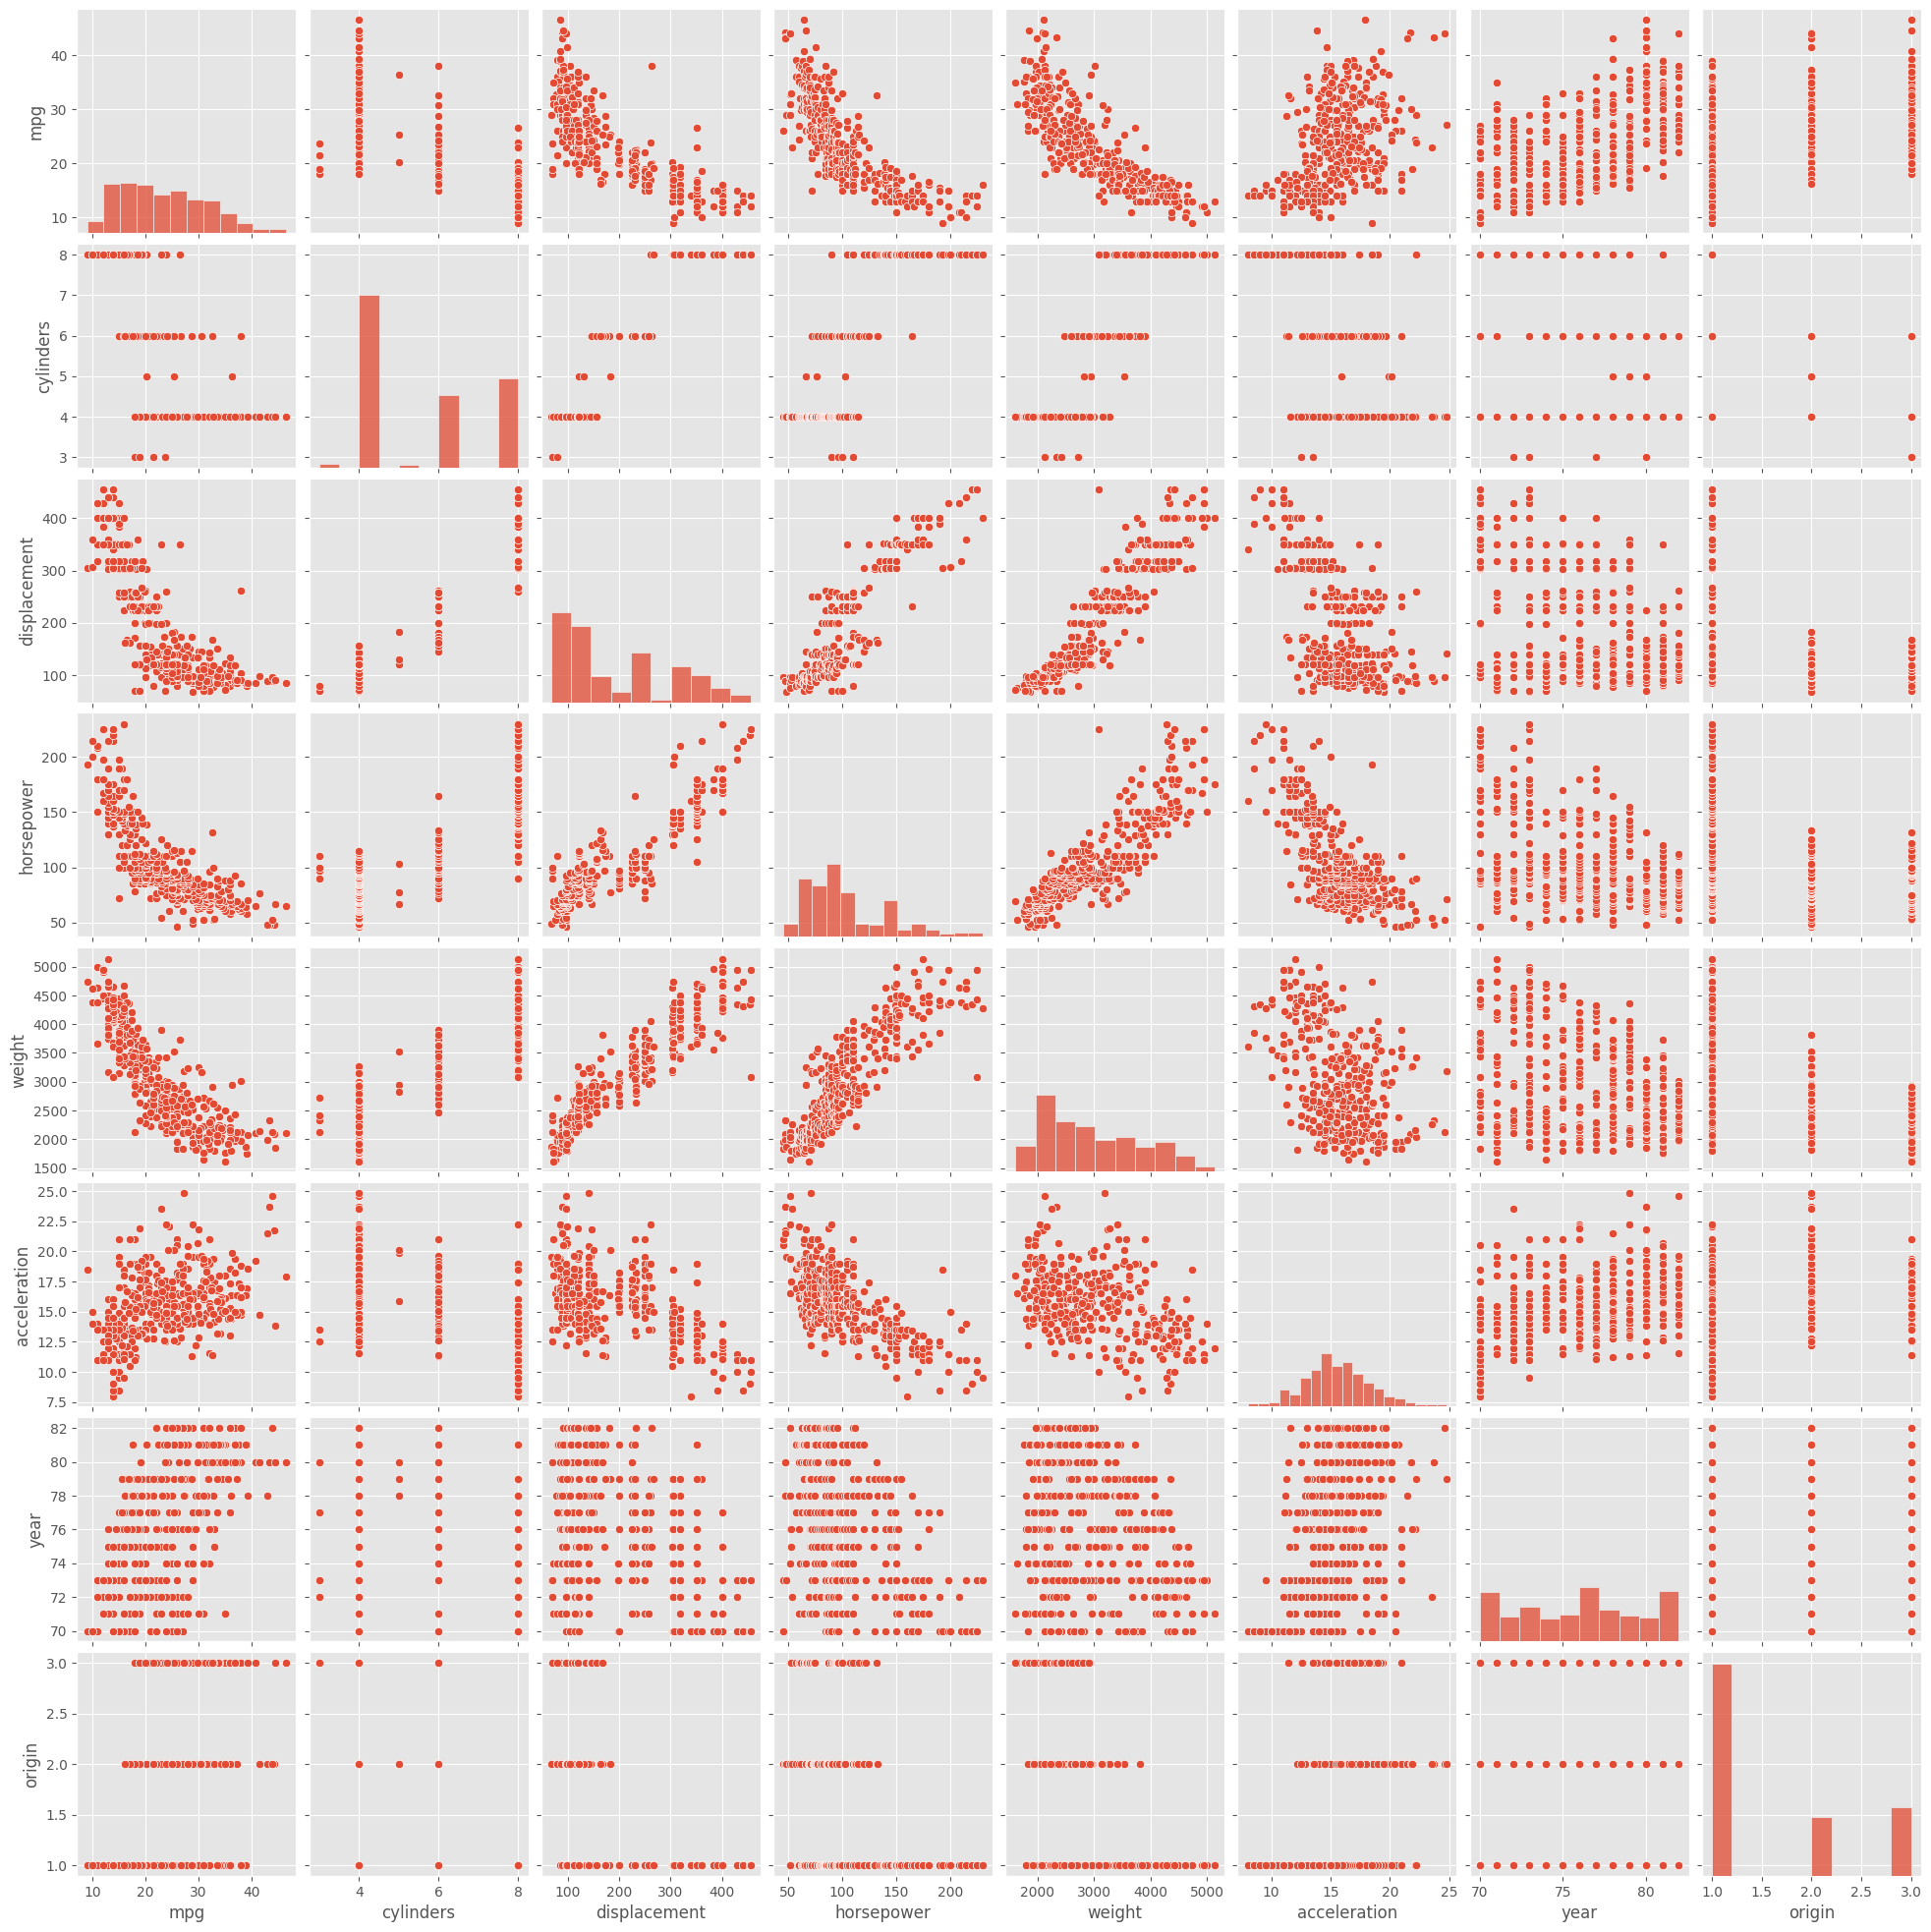

In [10]:
# Pairplot general de la base
sns.pairplot(auto)
plt.show()



## 6. Función para ajustar modelos polinomiales

Definimos una función para ajustar modelos de distinto grado.

La función recibe:

- `data`: base de datos.
- `var`: variable explicativa.
- `target`: variable objetivo.
- `degree`: grado del polinomio.

La salida de la función son los valores predichos por el modelo.


In [11]:
def fit_degree(data, var, target, degree):
    # Ajusta una regresion polinomial y devuelve las predicciones.
    poly = PolynomialFeatures(degree)
    poly_data = poly.fit_transform(data[var].to_frame())
    lin_model = LinearRegression(fit_intercept=False)
    lin_model.fit(poly_data, data[target])
    pred = lin_model.predict(poly_data)

    return pred


## 7. Comparación visual de modelos de grados 1, 2 y 5

Ahora ajustamos tres modelos:

- Grado 1: una recta.
- Grado 2: una curva cuadrática.
- Grado 5: una curva más flexible.

El objetivo no es escoger automáticamente el modelo más complejo, sino comparar cómo cambia el ajuste.


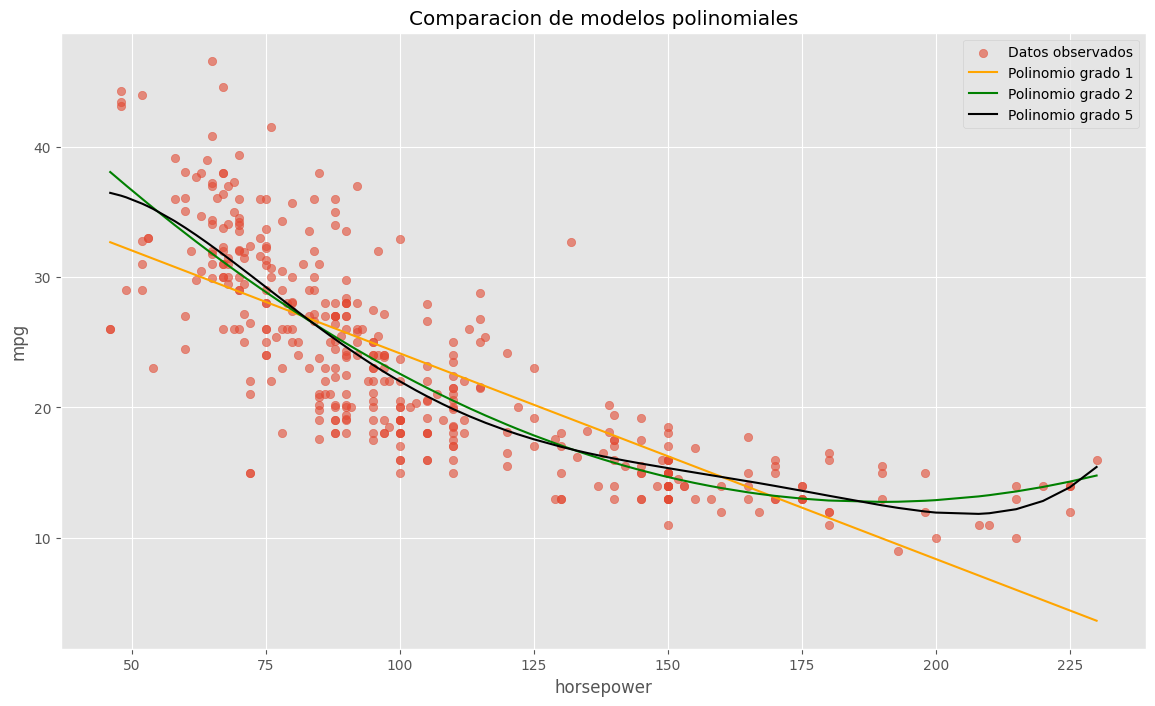

In [12]:
pred_1 = fit_degree(auto, 'horsepower', 'mpg', 1)
pred_2 = fit_degree(auto, 'horsepower', 'mpg', 2)
pred_5 = fit_degree(auto, 'horsepower', 'mpg', 5)

plt.figure(figsize=(14, 8))
plt.scatter(auto['horsepower'], auto['mpg'], alpha=0.6, label='Datos observados')
plt.plot(auto['horsepower'], pred_1, color='orange', label='Polinomio grado 1')
plt.plot(auto['horsepower'], pred_2, color='green', label='Polinomio grado 2')
plt.plot(auto['horsepower'], pred_5, color='black', label='Polinomio grado 5')

plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Comparacion de modelos polinomiales')
plt.legend()
plt.show()


### Interpretación de la gráfica

El modelo de grado 1 ajusta una línea recta. Captura la tendencia general negativa, pero puede ser demasiado simple.

El modelo de grado 2 permite una curvatura y suele describir mejor la relación entre potencia y rendimiento.

El modelo de grado 5 es más flexible. Puede ajustarse mejor a los datos observados, pero también puede empezar a seguir demasiado el ruido de la muestra. A esto se le conoce como **sobreajuste**.


## 8. Ajuste formal del modelo de grado 2

Ahora ajustamos el modelo de grado 2 usando `statsmodels`, porque esta librería nos permite obtener una tabla con coeficientes, errores estándar, valores p y medidas de ajuste.


In [13]:
poly_2 = PolynomialFeatures(2)
poly_data_2 = poly_2.fit_transform(auto['horsepower'].to_frame())

modelo2 = sm.OLS(auto['mpg'], poly_data_2)
resultados2 = modelo2.fit()

print(resultados2.summary())




                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           5.40e-99
Time:                        12:35:23   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.9001      1.800     31.604      0.0

### Cómo leer la tabla del modelo

Al revisar el resumen del modelo, conviene observar:

1. **Coeficientes**: indican cómo se combinan los términos del modelo.
2. **P>|t|**: ayuda a evaluar si cada término aporta información estadísticamente relevante.
3. **R-squared**: mide qué proporción de la variabilidad de `mpg` es explicada por el modelo.
4. **Adj. R-squared**: versión ajustada de $R^2$, útil cuando se comparan modelos con distinto número de variables.

Una interpretación sencilla es:

> Si el término cuadrático es significativo, entonces hay evidencia de que la relación entre `horsepower` y `mpg` no es simplemente una línea recta.


## 9. Ajuste formal del modelo de grado 1

El modelo de grado 1 servirá como referencia. Es el modelo más simple y representa una relación lineal entre `horsepower` y `mpg`.


In [14]:
poly_1 = PolynomialFeatures(1)
poly_data_1 = poly_1.fit_transform(auto['horsepower'].to_frame())

modelo1 = sm.OLS(auto['mpg'], poly_data_1)
resultados1 = modelo1.fit()

print(resultados1.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           7.03e-81
Time:                        12:35:23   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

## 10. Ajuste formal del modelo de grado 5

El modelo de grado 5 es más flexible porque incluye potencias hasta `horsepower^5`.

Sin embargo, más flexibilidad no siempre significa mejor modelo. Un modelo muy complejo puede ajustarse demasiado bien a los datos de entrenamiento, pero fallar al predecir datos nuevos.


In [15]:
poly_5 = PolynomialFeatures(5)
poly_data_5 = poly_5.fit_transform(auto['horsepower'].to_frame())

modelo5 = sm.OLS(auto['mpg'], poly_data_5)
resultados5 = modelo5.fit()

print(resultados5.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     177.4
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           1.16e-97
Time:                        12:35:23   Log-Likelihood:                -1127.3
No. Observations:                 392   AIC:                             2267.
Df Residuals:                     386   BIC:                             2290.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -32.2306     28.574     -1.128      0.2

## 11. Comparación de modelos con métricas

Para comparar los modelos podemos calcular:

- $R^2$: proporción de variabilidad explicada.
- RMSE: error cuadrático medio de predicción en la misma escala de la variable respuesta.

Un RMSE más pequeño indica que, en promedio, las predicciones están más cerca de los valores observados.


In [16]:
def metricas_modelo(y, y_pred, nombre):
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return {'Modelo': nombre, 'R2': r2, 'RMSE': rmse}

comparacion = pd.DataFrame([
    metricas_modelo(auto['mpg'], pred_1, 'Grado 1'),
    metricas_modelo(auto['mpg'], pred_2, 'Grado 2'),
    metricas_modelo(auto['mpg'], pred_5, 'Grado 5')
])

comparacion


,Modelo,R2,RMSE
0,Grado 1,0.605948,4.893226
1,Grado 2,0.687559,4.357151
2,Grado 5,0.695733,4.299778


### Interpretación de las métricas

Si el modelo de grado 2 mejora claramente respecto al modelo de grado 1, entonces la curvatura ayuda a explicar mejor los datos.

Si el modelo de grado 5 mejora muy poco respecto al de grado 2, quizá no vale la pena usar un modelo más complejo.

En aprendizaje supervisado, buscamos un equilibrio entre:

- Buen ajuste.
- Interpretabilidad.
- Capacidad de generalizar a datos nuevos.


## 12. Gráficos de residuales

Los residuales son las diferencias entre los valores observados y los valores predichos:

\[
residual = y - \hat{y}.
\]

Sirven para revisar si el modelo deja patrones sin explicar.

Un buen modelo debería tener residuales distribuidos alrededor de cero, sin una forma clara.


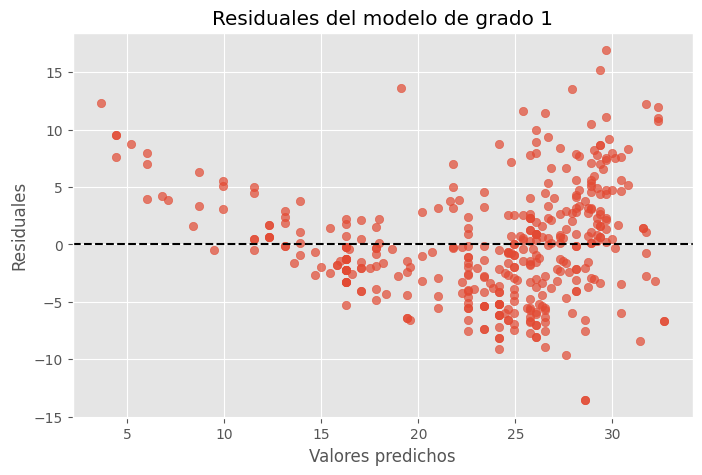

In [17]:
resid_1 = auto['mpg'] - pred_1
resid_2 = auto['mpg'] - pred_2
resid_5 = auto['mpg'] - pred_5

plt.figure(figsize=(8, 5))
plt.scatter(pred_1, resid_1, alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuales')
plt.title('Residuales del modelo de grado 1')
plt.show()


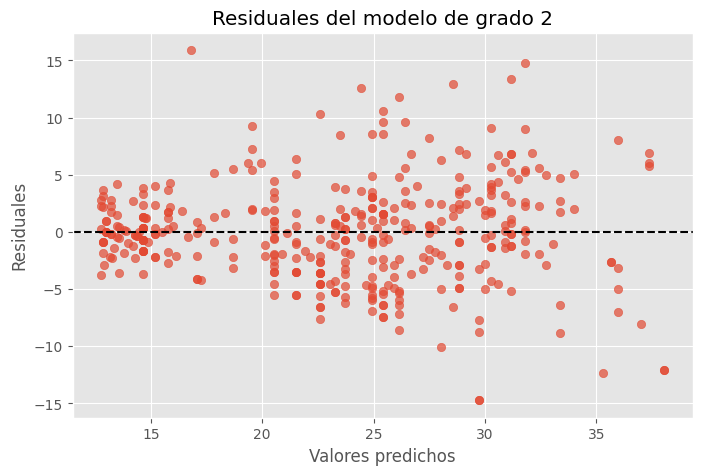

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(pred_2, resid_2, alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuales')
plt.title('Residuales del modelo de grado 2')
plt.show()


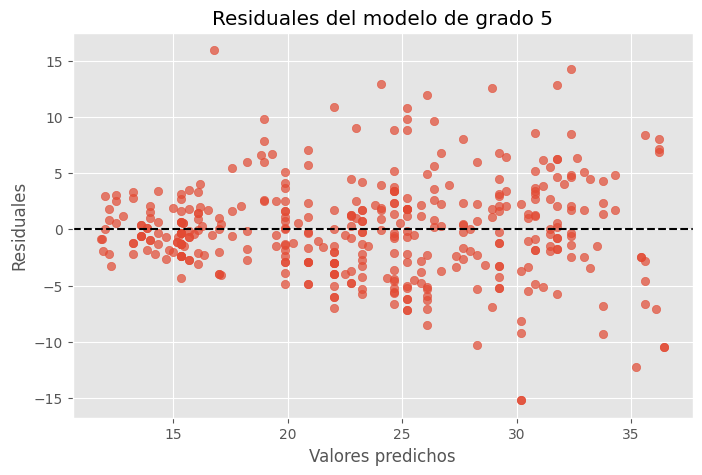

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(pred_5, resid_5, alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuales')
plt.title('Residuales del modelo de grado 5')
plt.show()


### Interpretación de los residuales

Para analizar los residuales, responde:

1. ¿Los puntos están alrededor de cero?
si pero con bastante dispersion
2. ¿Se observa una curva o patrón sistemático?
si se mira una curva por lo que el modelo parece muy simple
3. ¿La dispersión de los residuales es parecida en todo el rango de valores predichos?
no la dispersion cambia segun los valores predichos
4. ¿Hay observaciones muy alejadas del resto?
si hay puntos alejados

Si los residuales todavía muestran una curva, el modelo puede ser demasiado simple.

Si los residuales se ven muy irregulares y el modelo parece seguir demasiado a los datos, puede haber sobreajuste.


## 13. Validación con datos de entrenamiento y prueba

Hasta ahora evaluamos los modelos usando los mismos datos con los que fueron entrenados.

Para evaluar mejor la capacidad predictiva, separamos la base en:

- **Entrenamiento**: datos usados para ajustar el modelo.
- **Prueba**: datos usados para evaluar predicciones en datos no vistos.

Esto es importante porque un modelo puede ajustarse muy bien a los datos conocidos, pero no necesariamente predecir bien datos nuevos.


In [20]:
X = auto[['horsepower']]
y = auto['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123
)

resultados_test = []

for grado in [1, 2, 3, 4, 5]:
    poly = PolynomialFeatures(grado)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    modelo = LinearRegression(fit_intercept=False)
    modelo.fit(X_train_poly, y_train)

    pred_train = modelo.predict(X_train_poly)
    pred_test = modelo.predict(X_test_poly)

    resultados_test.append({
        'Grado': grado,
        'RMSE_train': np.sqrt(mean_squared_error(y_train, pred_train)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_test)),
        'R2_test': r2_score(y_test, pred_test)
    })

pd.DataFrame(resultados_test)


,Grado,RMSE_train,RMSE_test,R2_test
0,1,4.714109,5.307764,0.577059
1,2,4.177553,4.754051,0.660700
2,3,4.172740,4.749125,0.661403
3,4,4.171316,4.736258,0.663235
4,5,4.134394,4.656823,0.674436


### Interpretación de entrenamiento y prueba

Al comparar `RMSE_train` y `RMSE_test`:

- Si ambos errores son altos, el modelo puede estar subajustando.
- Si el error de entrenamiento es bajo pero el error de prueba es alto, puede haber sobreajuste.
- Si el error de prueba es razonablemente bajo, el modelo generaliza mejor.

Esta comparación ayuda a elegir un modelo no solo por cómo ajusta los datos conocidos, sino por cómo predice datos nuevos.


## 14. Conclusión

Con base en los resultados obtenidos, completa las siguientes ideas:

1. La relación entre `horsepower` y `mpg` parece ser ____negativa______.
2. El modelo lineal de grado 1 captura ___la tendencia genera_______, pero no necesariamente _____toda la relacion_____.
3. El modelo de grado 2 mejora porque permite ___modelar curvaturas_______.
4. El modelo de grado 5 es más flexible, pero se debe tener cuidado con _____el sobreajuste_____.
5. El modelo que elegiría para explicar los datos es el de grado ______2____ porque ofrece un buen equilibrio entre simplicidad y ajuste a los datos______.

Una conclusión posible es:

> La relación entre potencia y rendimiento no parece ser completamente lineal. A medida que aumenta la potencia del automóvil, el rendimiento tiende a disminuir. El modelo cuadrático permite representar mejor esta curvatura sin perder demasiada interpretabilidad. Aunque modelos de mayor grado pueden ajustarse mejor a los datos observados, deben evaluarse con cuidado para evitar sobreajuste.


## 15. Actividad
Utiliza como variabkle de respuesta mpg y como variable predictora weight y realiza las siguientes tareas:

1. Ajusta modelos polinomiales de grados 1, 2, 3, 4 y 5.
2. Compara sus valores de $R^2$ y RMSE.
3. Grafica los modelos sobre los datos observados.
4. Analiza los residuales del modelo que consideres más adecuado.
5. Explica cuál modelo elegirías y por qué.

Tu respuesta debe incluir una interpretación en lenguaje claro, no solo resultados numéricos.


In [21]:
# Espacio de trabajo para el estudiante
# Puedes usar este bloque para repetir el análisis con otros grados del polinomio.
